In [54]:
# Pacchetto per apertura dati salvati in cartelle zippate
import zipfile

# Pacchetti per analisi dati
#import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import seaborn as sns
import warnings; warnings.simplefilter("ignore")
from functools import reduce
from sklearn.linear_model import LinearRegression
import math
import pytz

# Pacchetti per visualizzazioni grafiche
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
from collections import Counter

<span style="font-size: x-large;">**GESTIONE DATI**</span>  
  
  **<span style="font-size: large;">1. dati davis**

In [55]:
percorso = "./DATI_ORIGINALI/"

# Il percorso va cambiato in funzione di dove sono i vostri dati
nome_file = "Dati_Stazione.zip"
file= str(percorso)+str(nome_file)

with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(percorso)

stazioni = ["A","B","C"]

for stazione in stazioni:
    
    print("Stazione "+stazione)

    file = percorso+"Dati Meteo - Stazione "+stazione+".txt"
    
    # Di seguito si inizializza una lista vuota, all'interno della quale si va a caricare ogni linea della tabella ".txt".
    # In questo contesto, è importante notare che ogni colonna dei file è separata da spazi bianchi, che devono essere tenuti 
    # in considerazione al momento del caricamento dei dati.
    # Per farlo, si adopera "line.split()", che legge riga per riga la tabella ".txt" (compreso il nome delle colonne) ed 
    # elimina tutti gli spazi tra una colonna e l'altra.

    lista = []
    with open(file, encoding='ISO-8859-1') as f:
        for line in f:
            l = line.split()
            lista.append(l)
    
    # A questo punto, trasformiamo la lista in un DataFrame di pandas, con le colonne nominate come nel file originale.
    df = pd.DataFrame(lista[1:],columns=lista[0])
    
    # Seppur non necessario ai fini delle analisi, con i prossimi due comandi si sistemano le intestazioni delle colonne:
    # 1. Eliminiamo la virgola alla fine dei nomi delle diverse colonne nel file originale (es. "wndSpeed,")
    df.columns = df.columns.str.rstrip(',')    
    # 2. Eliminiamo il carattere "#" di fronte alla parola "Date" della prima colonna ("#Date")
    nome_prima_colonna = df.columns[0][1:]
    df.rename(columns={df.columns[0]: nome_prima_colonna}, inplace=True)
    
    # I dati della stazione C presentano dei caratteri verso la fine dell'intervallo temporale che non sono facilmente decifrati/interpretati da python.
    # Si procede quindi a selezionare solo quelle righe del dataframe della stazione C dove tutte le colonne contengono solo 
    # caratteri alfabetici (a-zA-Z), caratteri numerici (0-9) e il segno meno (-).
    
    if stazione == "C":
        for col in range(df.shape[1]):
            column = df.columns[col]
            mask = df[str(column)].str.contains(r'^[a-zA-Z0-9.-]+$', na=False)
            df = df[mask]
    else:
        pass

#creo colonna Datetime
    day = df['Date'].values; hour = df['Time'].values
    date_final = np.array([datetime.strptime(data + ' ' + ora, "%Y%m%d %H.%M") for data, ora in zip(day, hour)])
    df.insert(2,'Datetime',date_final)
    df.drop(df.columns[:2],axis=1, inplace=True)
            
    df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
                    
#riordina by date
    df = df.sort_values(by='Datetime', ignore_index=True) #ricrea indici di riga da 0 a n-1
    df.set_index(df['Datetime'], inplace=True)
    df.index.name = None
    globals()["df_"+stazione] = df

Stazione A
Stazione B
Stazione C


In [56]:
df_A

,Datetime,Interval,Press,inTemp,outTemp,inHum,outHum,wndSpeed,wndDir,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
2005-09-22 03:00:00,2005-09-22 03:00:00,30.0,1017.27,22.22,14.28,44.0,76.0,0.447,270.0,2.235,292.5,0.0,0.0,10.1,14.28,14.28,0.0,0.0,0.8
2005-09-22 03:30:00,2005-09-22 03:30:00,30.0,1017.21,22.11,14.11,45.0,76.0,0.447,270.0,3.129,270.0,0.0,0.0,9.94,14.11,14.11,0.0,0.0,0.8
2005-09-22 04:00:00,2005-09-22 04:00:00,30.0,1017.31,22.06,13.94,45.0,76.0,0.447,270.0,2.682,270.0,0.0,0.0,9.78,13.94,13.94,0.0,0.0,0.8
2005-09-22 04:30:00,2005-09-22 04:30:00,30.0,1017.27,21.94,13.94,45.0,76.0,0.0,270.0,1.788,270.0,0.0,0.0,9.78,13.94,13.94,0.0,0.0,0.8
2005-09-22 05:00:00,2005-09-22 05:00:00,30.0,1017.17,21.83,13.89,45.0,76.0,0.447,292.5,2.235,315.0,0.0,0.0,9.73,13.89,13.89,0.0,0.0,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-10-22 11:00:00,2019-10-22 11:00:00,30.0,1023.03,23.83,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9
2019-10-22 11:30:00,2019-10-22 11:30:00,30.0,1023.07,23.89,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9
2019-10-22 12:00:00,2019-10-22 12:00:00,30.0,1023.03,23.89,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9
2019-10-22 12:30:00,2019-10-22 12:30:00,30.0,1022.83,23.89,-73.28,63.0,-99.9,-44.655,-99.9,0.0,-99.9,0.0,0.0,-73.28,-73.28,-73.28,0.0,-99.9,-99.9


**<span style="font-size: large;">Solo dati alle HH:00 o HH:30**

In [57]:
for stazione in stazioni:
    df = globals()["df_"+stazione].copy() #sono dati raw con colonna datetime unica e ordinata per datetime con nuovi indici
    
    globals()["df_"+stazione+"_interval30"] = df[((df.Datetime.dt.minute == 0)|(df.Datetime.dt.minute == 30))&(df.Interval == 30)]
    print(f"Stazione {stazione} " + str( globals()["df_"+stazione+"_interval30"].Interval.min())) #to verify


Stazione A 30.0
Stazione B 30.0
Stazione C 30.0


<span style="font-size: large;">**Filtro temporale Davis**<br>
Dal 2015 al 2016

In [58]:
def get_season(month):
    if 3 <= month <= 5:
        return 'MAM'
    elif 6 <= month <= 8:
        return 'JJA'
    elif 9 <= month <= 11:
        return 'SON'
    else:
        return 'DJF'

for stazione in stazioni:
    print("STAZIONE_"+stazione)
    df = globals()["df_"+stazione+"_interval30"].copy()  #sono dati raw con colonna datetime unica e ordinata per datetime con nuovi indici
    #aggiungo indice di stagione
    df['Stagione'] = df['Datetime'].dt.month.apply(get_season)
    #filtro anni di interesse
    df_year = df[(df["Datetime"].dt.year >= 2015)&(df["Datetime"].dt.year <= 2016)]
    globals()["df_"+stazione+"_year"] = df_year

    print("raw      " + str(globals()["df_"+stazione+"_interval30"].shape[0]))
    print("rimaste  " + str(globals()["df_"+stazione+"_year"].shape[0]))

STAZIONE_A
raw      192033
rimaste  35082
STAZIONE_B
raw      187243
rimaste  34947
STAZIONE_C
raw      85469
rimaste  35083


**<span style="font-size: large;">Dataframe ARPA** <br>
Temperatura, UR, press

In [59]:
percorso = "./DATI_ARPAE/"
files = ['tpavg', 'tpmax', 'tpmin', 'uravg', 'urmax', 'urmin', 'pressure']
for file in files:
    # Eliminiamo le prime 4 righe che sono dati testuali e gli ultimi valori dell'anno precedente
    df = pd.read_csv(percorso+'2015-2016_'+file+'_urbana.csv', encoding='ISO-8859-1',names=['Datetime UTC','Fine validità (UTC)',file],
                        skiprows=4,on_bad_lines='skip')
    # Eliminiamo inoltre le ultime righe che hanno solo dati testuali
    df = df[:-2]
    # Eliminiamo la colonna "Fine validità (UTC)" in quanto disponiamo dell'informazione sulla data già dalla prima colonna.
    # La seconda colonna ci sta solo ad indicare che le misure sono misure di vento orarie (come già noto dal sito web ARPAE).
    df.drop(df.columns[1],axis=1, inplace=True)

    # Trasformiamo la colonna tempo in formato Data Anno-Mese-Giorno ora:minuto (come fatto in precedenza)
    df['Datetime UTC'] = pd.to_datetime(df['Datetime UTC'])
    df[file] = df[file].astype(float) #tofloat

    #converti to local time
    local_timezone = pytz.timezone('Etc/GMT-2')
    df['Datetime'] = df['Datetime UTC'].dt.tz_convert(local_timezone)
    df['Datetime'] = df['Datetime'].dt.tz_localize(None)
    df.set_index(df['Datetime'], inplace=True)
    df.index.name = None
    df.drop(df.columns[0], axis=1, inplace=True)
    #print(str(df.Datetime.min()) + " " + str(df.Datetime.max()))
    #print(df.columns)
    if file == files[0]:
        df_ARPAE = df
    else:
        df_ARPAE = pd.merge(df_ARPAE, df, on='Datetime', suffixes=(None, '_'+file))
df_ARPAE.set_index(df_ARPAE['Datetime'], inplace=True)
df_ARPAE.index.name = None
df_ARPAE.pressure = df_ARPAE.pressure / 100
df_ARPAE

,tpavg,Datetime,tpmax,tpmin,uravg,urmax,urmin,pressure
2015-01-01 01:00:00,-1.6,2015-01-01 01:00:00,-1.5,-1.7,72.0,76.0,70.0,1025.3
2015-01-01 02:00:00,-1.6,2015-01-01 02:00:00,-1.5,-1.8,73.0,79.0,70.0,1025.5
2015-01-01 03:00:00,-1.8,2015-01-01 03:00:00,-1.7,-1.9,80.0,82.0,78.0,1025.9
2015-01-01 04:00:00,-1.8,2015-01-01 04:00:00,-1.7,-1.9,77.0,80.0,71.0,1025.9
2015-01-01 05:00:00,-1.7,2015-01-01 05:00:00,-1.5,-1.9,68.0,72.0,64.0,1025.4
...,...,...,...,...,...,...,...,...
2016-12-31 21:00:00,2.5,2016-12-31 21:00:00,2.8,2.2,70.0,70.0,69.0,1021.1
2016-12-31 22:00:00,2.3,2016-12-31 22:00:00,2.5,2.2,68.0,69.0,65.0,1020.6
2016-12-31 23:00:00,2.1,2016-12-31 23:00:00,2.3,1.9,65.0,66.0,63.0,1020.4
2017-01-01 00:00:00,1.8,2017-01-01 00:00:00,2.0,1.5,62.0,65.0,60.0,1019.9


<span style="font-size: x-large;">**ANALISI DELLA TEMPERATURA**<span style="font-size: x-large;">  

<span style="font-size: large;">**1. Filtro di plausibilità**

In [60]:
tpmax = df_ARPAE.tpmax.max()
tpmin = df_ARPAE.tpmin.min()
urmax = df_ARPAE.urmax.max()
urmin = df_ARPAE.urmin.min()
prmax = df_ARPAE.pressure.max()
prmin = df_ARPAE.pressure.min()
tpmax, tpmin, urmin, urmax, prmax, prmin

(np.float64(37.5),
 np.float64(-3.0),
 np.float64(10.0),
 np.float64(103.0),
 np.float64(1030.1),
 np.float64(967.2))

In [80]:
for stazione in stazioni:
    df = globals()["df_"+stazione+"_year"]
    print(df.shape[0])
    globals()["df_"+stazione+"_year_filt"] = df[(df.outHum <= 100) & (df.outHum >= urmin) & 
                                           (df.outTemp >= tpmin) & (df.outTemp <= tpmax) & 
                                           (df.Press >= prmin) & (df.Press <= prmax)]
    print(globals()["df_"+stazione+"_year_filt"].shape[0] / df.shape[0])
    print("tra -20 e -3 gradi " + str(df[(df.outTemp < tpmin) & (df.outTemp > -70)].shape[0]))
    print("tra 37.5 e 50 gradi " + str(df[(df.outTemp < 50) & (df.outTemp > tpmax)].shape[0]))

35082
0.9358645459209851
tra -20 e -3 gradi 0
tra 37.5 e 50 gradi 13
34947
0.8659112370160529
tra -20 e -3 gradi 0
tra 37.5 e 50 gradi 8
35083
0.9518570247698316
tra -20 e -3 gradi 70
tra 37.5 e 50 gradi 0


  <span style="font-size: large;">**2. Risoluzione variabili**  

In [62]:
for stazione in stazioni:
    print("stazione "+stazione)
    df = globals()["df_"+stazione+"_year_filt"]
    vars = ['outTemp', 'outHum', 'Press']
    for var in vars:
        col = df[var].copy() #filtro anni, risoluzione temp, plausibilita
        col = col.drop_duplicates()
        col = col.sort_values()
        #print(col)
        differences_col = np.diff(col)  # Compute consecutive differences
        #print(differences_col)
        resolution_col = np.min(differences_col) if len(differences_col) > 0 else None
        print(f"{var} Resolution: {resolution_col} units")

stazione A
outTemp Resolution: 0.04999999999999716 units
outHum Resolution: 1.0 units
Press Resolution: 0.029999999999972715 units
stazione B
outTemp Resolution: 0.04999999999999716 units
outHum Resolution: 1.0 units
Press Resolution: 0.029999999999972715 units
stazione C
outTemp Resolution: 0.04999999999999716 units
outHum Resolution: 1.0 units
Press Resolution: 0.029999999999972715 units


In [ ]:
for stazione in stazioni:
    display(globals()["df_"+stazione+"_year_filt"])

<span style="font-size: large;">**3. CONFRONTO TRA STAZIONI DIVERSE**  

Per confrontare i dati di due stazioni, si possono adoperare diversi indici statistici, quali ad esempio:
- Indice di correlazione,
- Mean Error (ME),
- Mean Absolute Error (MAE),
- Root Mean Square Error (RMSE),
- RMSE normalizzato con la media del dataset di riferimento,

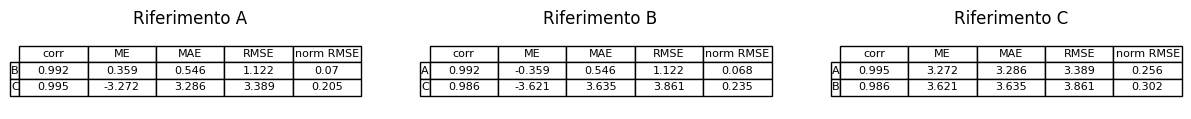

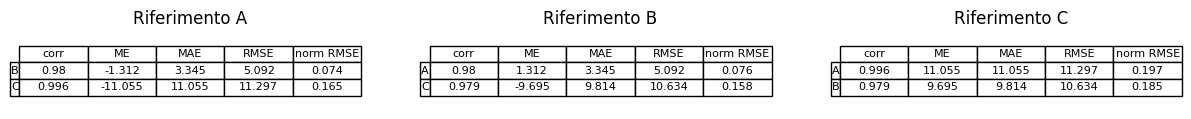

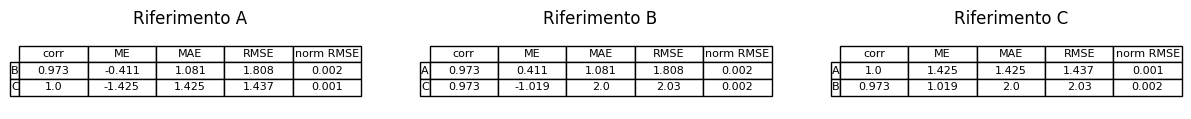

In [ ]:
import pandas as pd
import numpy as np

def statistics(var,ref):
    
    CORR = var.corrwith(ref)[0]
    ME = np.mean(np.subtract(var, ref))
    MAE = np.mean(np.abs(np.subtract(var, ref)))
    RMSE = np.sqrt(np.nanmean(np.square(np.subtract(var, ref))))
    nRMSE = RMSE / np.nanmean(ref)
    
    return CORR, ME, MAE, RMSE, nRMSE

def compare_column(ref, var, column_name):
    df = ref.copy()
    df_comp = var.copy()

    #seleziono dove stessa data
    common_index = list((df.index).intersection(df_comp.index))

    df_ref = df.loc[common_index].copy()
    df_to_comp = df_comp.loc[common_index].copy()
    corr,me,mae,rmse,nrmse = statistics(df_to_comp[[column_name]],df_ref[[column_name]])
    return corr,me,mae,rmse,nrmse

stazioni = ['A', 'B', 'C']
vars = ['outTemp', 'outHum', 'Press']
for var in vars:
    fig, axes = plt.subplots(1, 3, figsize=(3 * 5, 1))
    i = 0
    for riferimento in stazioni:
        rows = []
        #print("Riferimento "+riferimento)
        indexes = []
        for stazione in stazioni:
            if stazione != riferimento:
                indexes.append(stazione)
                corr, me, mae, rmse, nrmse = compare_column(globals()["df_"+riferimento+"_year_filt"], globals()["df_"+stazione+"_year_filt"], var)
                rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

        df = pd.DataFrame(rows, index=indexes, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
        #display(df)

        ax = axes[i]
        i +=1
        ax.axis('off')
        ax.set_title("Riferimento "+riferimento, loc='center')
        table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1)
    plt.savefig('FIGURE/'+var+'_compare_davis.png', dpi=300, bbox_inches='tight')


<span style="font-size: large;">**4. CONFRONTO DIFFERENZE NEL TEMPO DELLE STAZIONI**

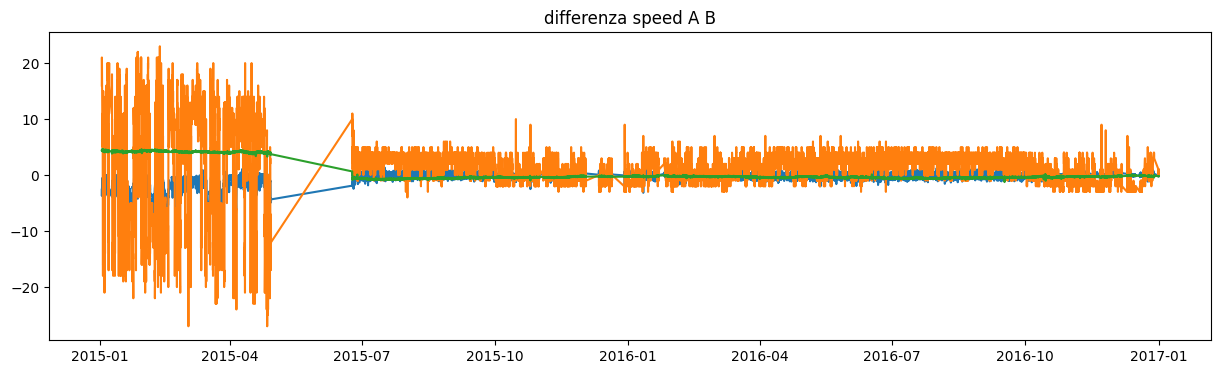

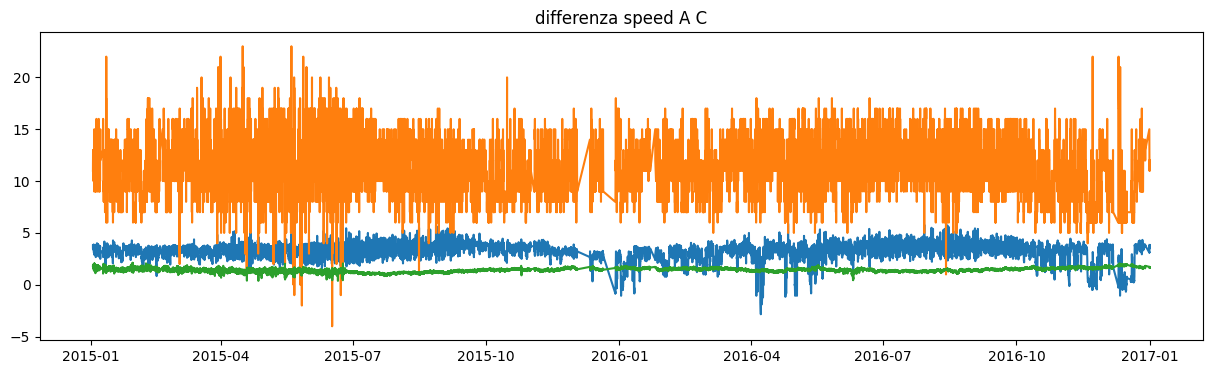

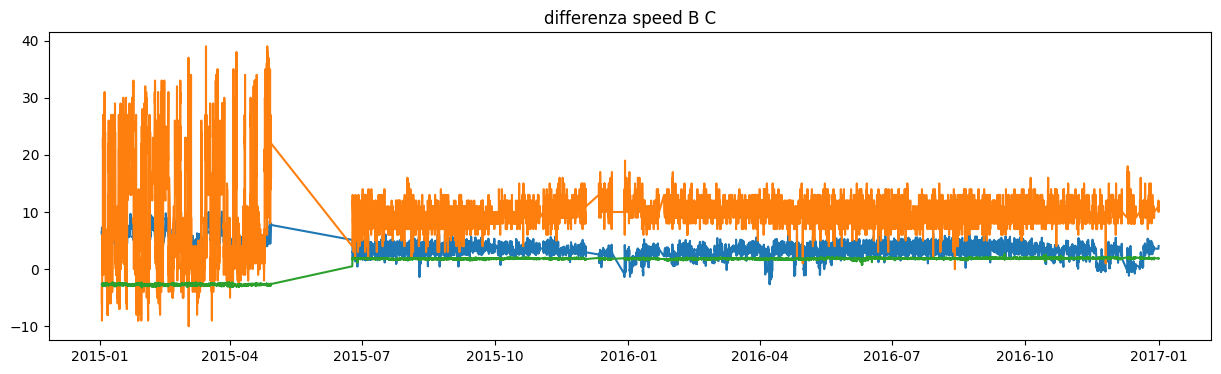

In [64]:
A = globals()["df_A_year_filt"]
B = globals()["df_B_year_filt"]
C = globals()["df_C_year_filt"]

vars = ['outTemp', 'outHum', 'Press']
for var in vars:
    df_merged = pd.merge(A, B, on='Datetime', suffixes=('_A', '_B'))
    plt.figure(1, figsize=(15, 4))
    plt.plot(df_merged["Datetime"], np.subtract(df_merged[var+"_A"], df_merged[var+"_B"]))
    plt.title("differenza speed A B")

    df_merged = pd.merge(A, C, on='Datetime', suffixes=('_A', '_C'))
    plt.figure(2, figsize=(15, 4))
    plt.plot(df_merged["Datetime"], np.subtract(df_merged[var+"_A"], df_merged[var+"_C"]))
    plt.title("differenza speed A C")

    df_merged = pd.merge(B, C, on='Datetime', suffixes=('_B', '_C'))
    plt.figure(3, figsize=(15, 4))
    plt.plot(df_merged["Datetime"], np.subtract(df_merged[var+"_B"], df_merged[var+"_C"]))
    plt.title("differenza speed B C")


<span style="font-size: x-large;">**Confronto con ARPA**<span style="font-size: x-large;">  

<span style="font-size: large;">**1.MEDIO DAVIS SU UN ORA**

In [65]:
for stazione in stazioni:
    df = globals()["df_"+stazione+"_year_filt"]
    print(stazione)
    df['hour'] = df['Datetime'].dt.floor('H') #arrotondo ora precedente
    df['Datetime'] = df['hour']
    df = df.drop('Stagione', axis=1).groupby('hour').mean() #elimino stagione che non si può mediare
    df['Interval'] = 60
    display(df)
    globals()["df_"+stazione+"_year_1h"] = df

A


,Datetime,Interval,Press,inTemp,outTemp,inHum,outHum,wndSpeed,wndDir,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
hour,,,,,,,,,,,,,,,,,,,
2015-01-02 14:00:00,2015-01-02 14:00:00,60,1029.755,16.195,8.14,31.0,51.0,1.1175,303.75,3.3525,315.0,0.0,0.0,-1.39,8.14,8.14,0.065,209.0,1.25
2015-01-02 15:00:00,2015-01-02 15:00:00,60,1029.345,16.305,8.305,31.0,54.0,0.894,303.75,2.4585,337.5,0.0,0.0,-0.455,8.305,8.305,0.05,145.0,1.0
2015-01-02 16:00:00,2015-01-02 16:00:00,60,1028.775,16.36,7.86,31.5,58.0,0.447,281.25,1.788,270.0,0.0,0.0,0.115,7.86,7.86,0.025,44.5,0.3
2015-01-02 17:00:00,2015-01-02 17:00:00,60,1028.67,16.47,7.475,32.0,58.0,0.447,270.0,2.0115,270.0,0.0,0.0,-0.25,7.475,7.475,0.015,2.0,0.0
2015-01-02 18:00:00,2015-01-02 18:00:00,60,1028.7,16.56,7.165,32.0,61.5,0.447,270.0,2.0115,292.5,0.0,0.0,0.265,7.165,7.165,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00,2016-12-31 19:00:00,60,1030.04,20.22,5.22,29.0,74.0,0.447,315.0,1.788,315.0,0.0,0.0,0.97,5.22,5.22,0.03,0.0,0.0
2016-12-31 20:00:00,2016-12-31 20:00:00,60,1029.77,20.11,4.305,30.0,77.0,0.2235,315.0,1.1175,315.0,0.0,0.0,0.63,4.305,4.305,0.015,0.0,0.0
2016-12-31 21:00:00,2016-12-31 21:00:00,60,1029.485,20.11,3.805,30.0,77.5,0.2235,315.0,0.894,315.0,0.0,0.0,0.24,3.805,3.805,0.0,0.0,0.0


B


,Datetime,Interval,Press,inTemp,outTemp,inHum,outHum,wndSpeed,wndDir,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
hour,,,,,,,,,,,,,,,,,,,
2015-01-01 06:00:00,2015-01-01 06:00:00,60,1029.94,15.17,0.665,25.0,60.5,0.6705,270.0,3.7995,281.25,0.0,0.0,-6.095,0.665,0.665,0.015,0.0,1.0
2015-01-01 07:00:00,2015-01-01 07:00:00,60,1029.94,15.17,1.5,24.0,57.0,1.341,247.5,4.47,225.0,0.0,0.0,-6.09,1.5,1.5,0.03,0.0,1.0
2015-01-01 14:00:00,2015-01-01 14:00:00,60,1030.08,16.28,9.0,22.0,38.0,0.447,337.5,3.129,337.5,0.0,0.0,-4.56,9.0,9.0,0.0,255.0,1.5
2015-01-02 01:00:00,2015-01-02 01:00:00,60,1029.99,15.415,2.695,26.0,67.5,0.6705,258.75,2.9055,258.75,0.0,0.0,-2.71,2.695,2.695,0.0,0.0,1.0
2015-01-02 02:00:00,2015-01-02 02:00:00,60,1029.925,15.36,3.08,26.0,65.0,0.894,281.25,3.3525,270.0,0.0,0.0,-2.855,3.08,3.08,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-28 21:00:00,2016-12-28 21:00:00,60,1029.87,21.39,10.525,26.5,43.0,2.235,270.0,5.1405,258.75,0.0,0.0,-1.53,10.525,10.525,0.04,0.0,0.0
2016-12-31 20:00:00,2016-12-31 20:00:00,60,1029.8,20.94,4.06,29.0,77.0,0.447,247.5,1.341,247.5,0.0,0.0,0.39,4.06,4.06,0.0,0.0,0.0
2016-12-31 21:00:00,2016-12-31 21:00:00,60,1029.735,20.94,3.885,29.0,77.5,0.6705,270.0,1.341,270.0,0.0,0.0,0.32,3.885,3.885,0.015,0.0,0.0


C


,Datetime,Interval,Press,inTemp,outTemp,inHum,outHum,wndSpeed,wndDir,windGust,wGstDir,rainRate,rain,dewpoint,wdChill,heatIndx,ET,totRad,UV
hour,,,,,,,,,,,,,,,,,,,
2015-01-02 12:00:00,2015-01-02 12:00:00,60,1029.91,15.89,3.67,32.0,41.0,1.341,292.5,3.576,292.5,0.0,0.0,-8.36,3.67,3.67,0.0,320.0,1.9
2015-01-02 13:00:00,2015-01-02 13:00:00,60,1028.825,16.0,4.17,32.0,39.5,0.894,315.0,3.3525,292.5,0.0,0.0,-8.385,4.17,4.17,0.065,247.5,1.9
2015-01-02 14:00:00,2015-01-02 14:00:00,60,1027.875,16.14,4.5,32.0,39.0,0.6705,315.0,2.9055,337.5,0.0,0.0,-8.25,4.5,4.5,0.05,201.5,1.7
2015-01-02 15:00:00,2015-01-02 15:00:00,60,1027.465,16.25,4.72,32.0,42.0,0.6705,315.0,2.235,303.75,0.0,0.0,-7.095,4.72,4.72,0.05,121.5,1.45
2015-01-02 16:00:00,2015-01-02 16:00:00,60,1027.045,16.33,4.22,32.0,45.0,0.0,315.0,1.341,168.75,0.0,0.0,-6.65,4.22,4.22,0.025,38.0,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00,2016-12-31 19:00:00,60,1028.4,20.11,1.28,30.0,63.0,0.0,-99.9,0.0,-99.9,0.0,0.0,-4.985,1.28,1.28,0.0,0.0,0.9
2016-12-31 20:00:00,2016-12-31 20:00:00,60,1028.11,20.11,0.72,30.0,65.0,0.0,-99.9,0.0,-99.9,0.0,0.0,-5.1,0.72,0.72,0.0,0.0,0.9
2016-12-31 21:00:00,2016-12-31 21:00:00,60,1027.79,20.11,0.14,30.0,66.0,0.0,-99.9,0.0,-99.9,0.0,0.0,-5.45,0.14,0.14,0.0,0.0,0.9


stesso nome a tp ur press in tabelle davis

In [66]:
for stazione in stazioni:
    print(stazione)
    df = globals()["df_"+stazione+"_year_1h"]
    df.rename(columns={"outTemp": "tpavg", "outHum": "uravg", "Press": "pressure"}, inplace=True)

A
B
C


<span style="font-size: large;">**2. CONFRONTO DAVIS ARAPE**

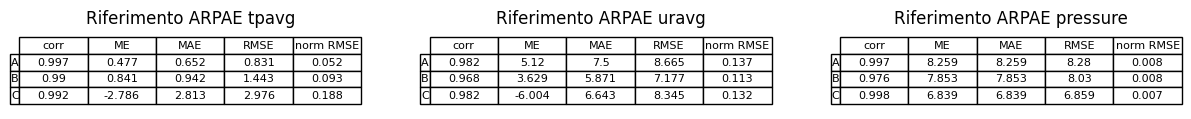

In [67]:
stazioni = ['A', 'B', 'C']
vars = ['tpavg', 'uravg', 'pressure']
fig, axes = plt.subplots(1, 3, figsize=(3 * 5, 1))
i = 0
for var in vars:
    rows = []
    for stazione in stazioni:
        corr, me, mae, rmse, nrmse = compare_column(globals()["df_ARPAE"], globals()["df_"+stazione+"_year_1h"], var)
        rows.append([round(corr,3), round(me,3), round(mae,3), round(rmse,3), round(nrmse,3)])

    df = pd.DataFrame(rows, index=stazioni, columns=['corr', 'ME', 'MAE', 'RMSE', 'norm RMSE'])
    
    #table image from dataframe
    ax = axes[i]
    i +=1
    ax.axis('off')
    ax.set_title("Riferimento ARPAE "+var, loc='center')
    table = pd.plotting.table(ax, df, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1)
    
plt.savefig('FIGURE/tp_ur_pr_compare_arpae.png', dpi=300, bbox_inches='tight')

<span style="font-size: large;">**3. REGRESSIONE LINEARE temp C - arpae**

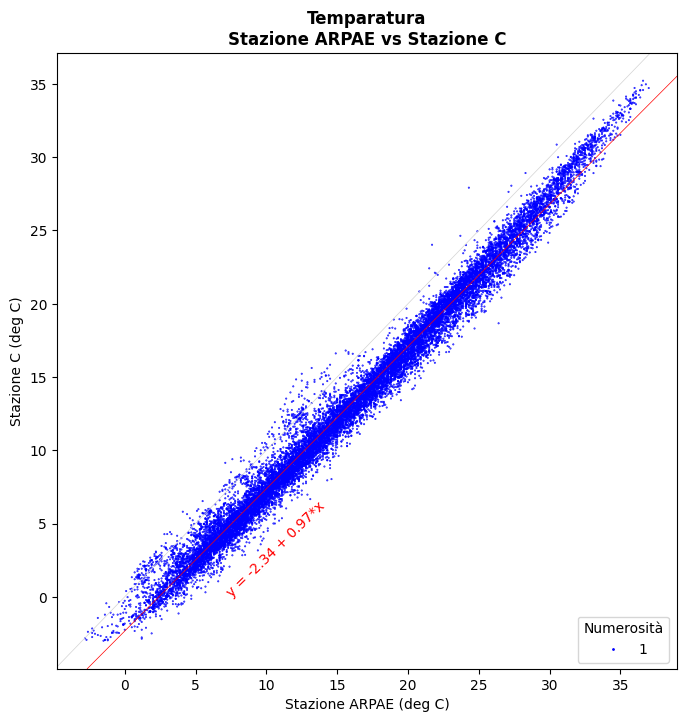

In [79]:
df_C = globals()["df_C_year_1h"][['Datetime','tpavg']]
df_merged = pd.merge(df_C, df_ARPAE, on='Datetime', suffixes=('_C', '_ARPAE'))
#display(df_merged)
df_merged = df_merged.dropna()

# Regressione Lineare
model = LinearRegression()
model.fit(df_merged['tpavg_ARPAE'].to_numpy().reshape((-1, 1)), df_merged['tpavg_C'].to_numpy()) #training data arpae
#reshape -1 lascia libero il numero di righe, qui diventa [[1.6],[0.2],...] (1 colonna)
intercept = model.intercept_
slope = model.coef_[0]

# Definizione delle grandezze dei marker, in funzione della numerosità
c = Counter( zip(df_merged['tpavg_ARPAE'], df_merged['tpavg_C']) ) #crea tuple di tuple: ( (arr[0], brr[0]), (arr[1], brr[1]) )
s = [0.2*c[(xx,yy)] for xx,yy in zip(df_merged['tpavg_ARPAE'],df_merged['tpavg_C'])]

fig, ax = plt.subplots(figsize=(8,8))

# Linea diagonale, che rappresenta una relazione lineare tra le due stazioni
ax.axline((1, 1), slope=1, color='lightgrey',linewidth=0.5)
ax.axline((0, intercept), slope=slope, color='red',linewidth=0.5) 

scatter_plot = plt.scatter(df_merged['tpavg_ARPAE'], df_merged['tpavg_C'], s=s, color='blue', label='Numero di occorrenze')

plt.xlabel('Stazione ARPAE (deg C)')
plt.ylabel('Stazione C (deg C)')
#plt.xlim(-1,12)
#plt.ylim(-1,12)

ax.legend(*scatter_plot.legend_elements(prop="sizes", num=[1,2,5,10,20], color='blue'), loc=(0.84,0.01),title='Numerosità')

plt.text(7,0,f'y = {round(intercept,2)} + {round(slope,2)}*x',rotation=np.rad2deg(math.atan(slope)),color='red')
plt.title('Temparatura\nStazione ARPAE vs Stazione C', fontweight="bold")

plt.savefig('FIGURE/correctionC.png', dpi=300, bbox_inches='tight')


Text(0.5, 1.0, 'Temparatura\nStazione ARPAE vs Stazione C')

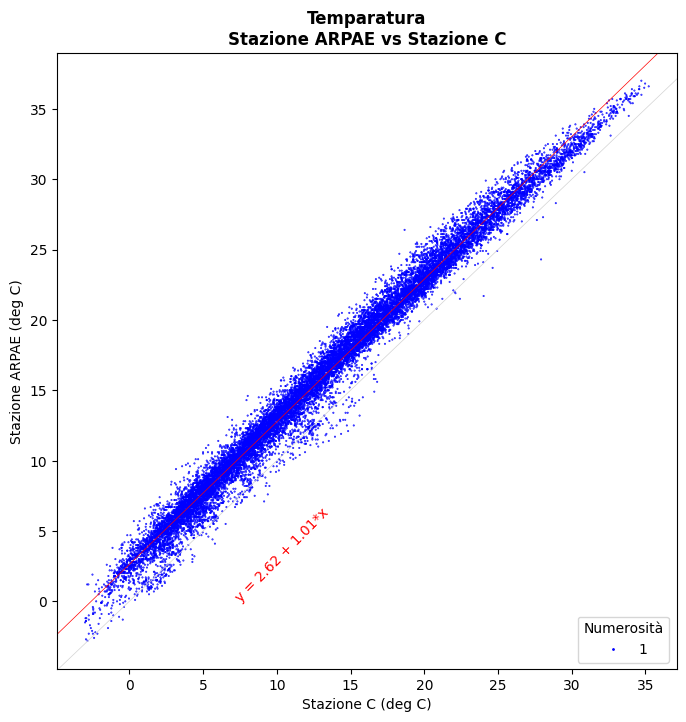

In [ ]:
df_C = globals()["df_C_year_1h"][['Datetime','tpavg']]
df_merged = pd.merge(df_C, df_ARPAE, on='Datetime', suffixes=('_C', '_ARPAE'))
#display(df_merged)
df_merged = df_merged.dropna()

# Regressione Lineare
model = LinearRegression()
model.fit(df_merged['tpavg_C'].to_numpy().reshape((-1, 1)), df_merged['tpavg_ARPAE'].to_numpy()) #training data arpae
#reshape -1 lascia libero il numero di righe, qui diventa [[1.6],[0.2],...] (1 colonna)
#in X possono esserci più caratteristiche che corrispondono alla stessa y, es [ [1.6, 87], [0.2, 99] ]
intercept = model.intercept_
slope = model.coef_[0]

# Definizione delle grandezze dei marker, in funzione della numerosità
c = Counter( zip(df_merged['tpavg_C'], df_merged['tpavg_ARPAE']) ) #crea tuple di tuple: ( (arr[0], brr[0]), (arr[1], brr[1]) )
s = [0.2*c[(xx,yy)] for xx,yy in zip(df_merged['tpavg_C'],df_merged['tpavg_ARPAE'])]

fig, ax = plt.subplots(figsize=(8,8))

# Linea diagonale, che rappresenta una relazione lineare tra le due stazioni
ax.axline((1, 1), slope=1, color='lightgrey',linewidth=0.5)
ax.axline((0, intercept), slope=slope, color='red',linewidth=0.5) 

scatter_plot = plt.scatter(df_merged['tpavg_C'], df_merged['tpavg_ARPAE'], s=s, color='blue', label='Numero di occorrenze')

plt.xlabel('Stazione C (deg C)')
plt.ylabel('Stazione ARPAE (deg C)')
#plt.xlim(-1,12)
#plt.ylim(-1,12)

ax.legend(*scatter_plot.legend_elements(prop="sizes", num=[1,2,5,10,20], color='blue'), loc=(0.84,0.01),title='Numerosità')

plt.text(7,0,f'y = {round(intercept,2)} + {round(slope,2)}*x',rotation=np.rad2deg(math.atan(slope)),color='red')
plt.title('Temparatura\nStazione ARPAE vs Stazione C', fontweight="bold")

#plt.savefig('FIGURE/correctionC.png', dpi=300, bbox_inches='tight')


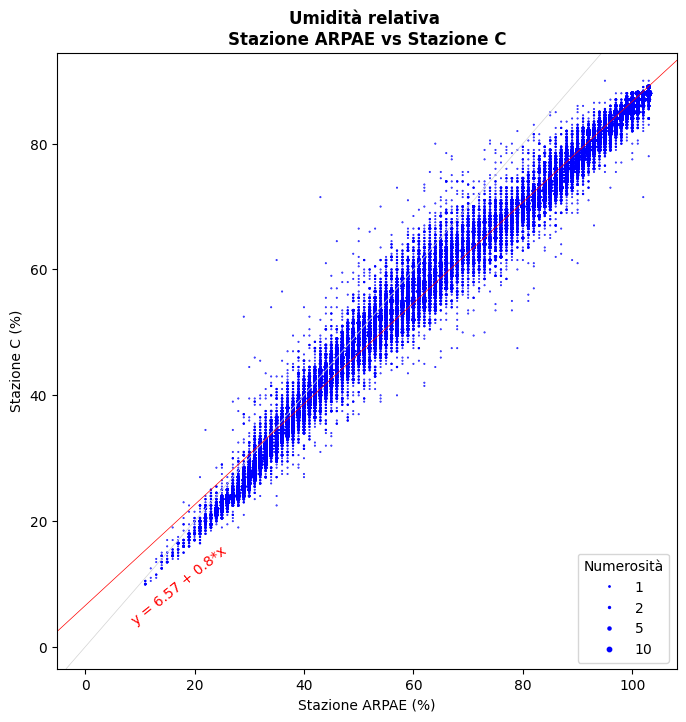

In [71]:
df_A = globals()["df_C_year_1h"][['Datetime','uravg']]
df_merged = pd.merge(df_A, df_ARPAE, on='Datetime', suffixes=('_C', '_ARPAE'))
#display(df_merged)
df_merged = df_merged.dropna()

# Regressione Lineare
model = LinearRegression()
model.fit(df_merged['uravg_ARPAE'].to_numpy().reshape((-1, 1)),df_merged['uravg_C'].to_numpy())
intercept = model.intercept_
slope = model.coef_[0]

# Definizione delle grandezze dei marker, in funzione della numerosità
c = Counter(zip(df_merged['uravg_ARPAE'],df_merged['uravg_C']))
s = [0.2*c[(xx,yy)] for xx,yy in zip(df_merged['uravg_ARPAE'],df_merged['uravg_C'])]

fig, ax = plt.subplots(figsize=(8,8))

# Linea diagonale, che rappresenta una relazione lineare tra le due stazioni
ax.axline((1, 1), slope=1, color='lightgrey',linewidth=0.5)
ax.axline((0, intercept), slope=slope, color='red',linewidth=0.5) 

scatter_plot = plt.scatter(df_merged['uravg_ARPAE'],df_merged['uravg_C'],s=s,color='blue',label='Numero di occorrenze')

plt.xlabel('Stazione ARPAE (%)')
plt.ylabel('Stazione C (%)')
#plt.xlim(-1,12)
#plt.ylim(-1,12)

ax.legend(*scatter_plot.legend_elements(prop="sizes", num=[1,2,5,10,20],color='blue'), loc=(0.84,0.01),title='Numerosità')

plt.text(8,3.5,f'y = {round(intercept,2)} + {round(slope,2)}*x',rotation=np.rad2deg(math.atan(slope)),color='red')
plt.title('Umidità relativa \nStazione ARPAE vs Stazione C', fontweight="bold")

plt.show()
